# 기계학습기초 팀 프로젝트

## KNHANES 2022 기반 수면시간·청각 문제와 우울 위험군 예측

- 팀명: 5팀
- 데이터: 국민건강영양조사 제9기 1차년도(2022년)
- 사용 데이터 형태: 이미 하나의 데이터셋으로 병합된 KNHANES 원시자료
- 주제: 수면시간, 청각 문제, 소음 노출 관련 변수를 활용한 우울 위험군 이진 분류
- 최종 산출물: 데이터 분석 전 과정을 포함한 Jupyter Notebook

---

# 0. 프로젝트 개요

## 0.1 연구 배경

본 프로젝트는 국민건강영양조사 제9기 1차년도(2022년) 자료를 활용하여 수면시간, 청각 문제, 소음 노출 관련 요인과 우울 위험군 사이의 관계를 분석한다.

## 0.2 문제 정의

- 입력 변수: 수면시간, 청각 상태, 직업적 소음 노출, 이명, 이어폰 소음 노출, 청각 활동제한 관련 변수
- 타깃 변수: PHQ-9 총점 기반 우울 위험군 여부
- 문제 유형: 지도학습 기반 이진 분류

## 0.3 분석 목표

- PHQ-9 총점 10점 이상 여부를 기준으로 우울 위험군 예측
- 수면 및 청각 관련 변수의 예측 기여도 확인
- 여러 분류 모델의 성능 비교
- 변수 중요도 및 도메인 관점 해석

## 0.4 분석 시 주의점

본 프로젝트에서는 이미 하나의 파일로 병합된 KNHANES 데이터를 사용하므로 별도의 데이터 병합 과정은 수행하지 않는다. 또한 PHQ-9 총점에는 수면 관련 문항이 포함되어 있으므로, 수면시간 변수와 우울 위험군 타깃 사이에 개념적 중복 가능성이 있음을 한계점에서 함께 해석한다.

---

# 1. 라이브러리 및 기본 설정

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

---

# 2. 데이터 불러오기

## 2.1 사용 데이터

국민건강영양조사 제9기 1차년도(2022년) 자료 중 이미 병합되어 있는 단일 데이터셋을 사용한다.

아래 코드에서 `file_path`만 실제 파일명에 맞게 수정하면 된다.

In [2]:
# 사용 중인 파일명에 맞게 수정하세요.
# 예: "hn22_all.sas7bdat", "final_dataset.csv", "knhanes_2022.csv"
file_path = "hn22_all.sas7bdat"

if file_path.endswith(".sas7bdat"):
    df_raw = pd.read_sas(file_path, format="sas7bdat")
elif file_path.endswith(".csv"):
    df_raw = pd.read_csv(file_path)
elif file_path.endswith((".xlsx", ".xls")):
    df_raw = pd.read_excel(file_path)
else:
    raise ValueError("지원하지 않는 파일 형식입니다. sas7bdat, csv, xlsx 중 하나를 사용하세요.")

# SAS 파일에서 문자형 변수가 bytes로 읽히는 경우 디코딩
for col in df_raw.columns:
    if df_raw[col].dtype == "object":
        df_raw[col] = df_raw[col].apply(
            lambda x: x.decode("cp949", errors="ignore") if isinstance(x, bytes) else x
        )

print("데이터 크기:", df_raw.shape)
df_raw.head()

데이터 크기: (6265, 685)


,mod_d,ID,ID_fam,year,region,town_t,apt_t,psu,sex,age,age_month,incm,ho_incm,incm5,ho_incm5,edu,occp,wt_hs,wt_itvex,wt_oe,wt_bia,wt_ntr,wt_tot,wt_oent,wt_biant,kstrata,cfam,genertn,allownc,house,live_t,ainc_unit1,ainc_1,ainc,marri_1,marri_2,fam_rela,tins,npins,ID_F,ID_M,D_1_1,D_2_1,D_2_wk,DI1_dg,DI1_ag,DI1_pr,DI1_pt,DI1_2,DI2_dg,...,Y_MLK_ST,Y_WN_ST,Y_SUP_YN,Y_SUP_KD1,Y_SUP_KD3,Y_SUP_KD4,Y_SUP_KD7,N_DIET,N_DIET_WHY,N_DT_DS,N_DT_ETC,N_WAT_C,N_BF,N_BFD_Y,N_DAY,N_INTK,N_EN,N_WATER,N_PROT,N_FAT,N_SFA,N_MUFA,N_PUFA,N_N3,N_N6,N_CHOL,N_CHO,N_TDF,N_SUGAR,N_CA,N_PHOS,N_NA,N_K,N_MG,N_FE,N_ZN,N_VA_RAE,N_VITD,N_VITE,N_CAROT,N_RETIN,N_B1,N_B2,N_NIAC,N_FOLATE,N_VITC,LF_secur_y,LF_BUYER,LF_SAFE,N_DUSUAL
0,2026.02.27.,YA01220302,YA012203,2022.0,1.0,1.0,2.0,YA01,2.0,56.0,NaN,3.0,4.0,4.0,4.0,3.0,7.0,7834.391511,9090.322425,10783.493262,11291.368622,10346.361689,10343.746528,11265.895141,11741.501904,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,1.0,1.0,2.0,10.0,1.0,NaN,NaN,3.0,2.0,88.0,1.0,48.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,3.5,2.0,8.0,수요일,849.465975,1460.144833,513.082135,58.852416,28.463777,8.017655,9.421072,7.647123,0.882515,6.761384,40.991353,238.931003,29.240249,44.705424,498.323785,1003.351910,1273.050326,2480.515348,371.132271,10.380525,10.240582,454.396392,2.150000,7.365415,853.187240,383.340000,0.814587,1.182300,10.042185,291.264557,32.441192,1.0,NaN,1.0,3
1,2026.02.27.,YA01220303,YA012203,2022.0,1.0,1.0,2.0,YA01,1.0,30.0,NaN,3.0,4.0,3.0,4.0,4.0,3.0,7834.391511,13042.142562,20078.947634,19822.942221,19763.950889,19666.742049,21352.961071,20820.115372,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,2.0,88.0,3.0,10.0,1.0,NaN,YA01220302,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,14.9,8.0,8.0,수요일,1441.052658,1971.535569,998.779824,98.998643,59.509129,14.244400,25.674881,11.391725,0.802900,10.573850,361.378293,268.663768,47.771905,102.638985,742.705707,1692.230686,1968.873043,3676.696548,520.241317,19.408543,14.736918,815.571495,5.498400,11.608507,973.767210,732.385000,1.829417,2.017004,18.342991,329.385371,79.903529,1.0,NaN,1.0,3
2,2026.02.27.,YA01220304,YA012203,2022.0,1.0,1.0,2.0,YA01,2.0,25.0,NaN,3.0,4.0,4.0,4.0,4.0,7.0,7834.391511,9895.727513,14566.872199,14931.827386,14314.436646,14510.887963,15616.336412,15501.618290,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,2.0,88.0,3.0,10.0,1.0,NaN,YA01220302,2.0,1.0,3.0,0.0,888.0,8.0,8.0,8.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,10.0,2.0,8.0,수요일,377.138748,1164.875037,131.628999,22.740898,39.650722,13.289250,15.123441,8.740357,0.354360,7.035220,0.961147,176.112561,10.117903,26.400092,423.150590,300.822929,1498.745141,783.549944,105.706399,2.591360,2.285068,14.093456,0.000000,8.502485,166.686411,0.000000,0.262020,1.379288,3.042505,69.694336,2.776080,1.0,1.0,1.0,2
3,2026.02.27.,YA01236501,YA012365,2022.0,1.0,1.0,2.0,YA01,1.0,66.0,NaN,3.0,3.0,4.0,3.0,4.0,7.0,7834.391511,6438.920648,7251.845005,7542.480144,7068.650323,7051.216076,7843.924333,8088.513725,101.0,2.0,2.0,20.0,2.0,2.0,1.0,4800.0,400.0,1.0,1.0,1.0,20.0,1.0,NaN,NaN,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,5.0,8.0,8.0,화요일,3245.543916,2213.970700,2744.107388,91.387506,66.330671,16.131310,23.075432,18.333469,3.835584,14.137622,325.006948,321.141632,48.315870,65.847307,552.891309,1441.801023,4157.860611,4448.107487,480.592319,16.433790,17.301592,407.893533,3.230366,9.215554,3676.549476,100.898983,1.338621,2.325439,18.325182,633.687278,112.775603,1.0,NaN,1.0,2
4,2026.02.27.,YA01236502,YA012365,2022.0,1.0,1.0,2.0,YA01,2.0,62.0,NaN,3.0,3.0,3.0,3.0,3.0,6.0,7834.391511,5593.752658,6857.115069,7064.391215,6434.393479,6420.343834,7194.949559,7421.746687,101.0,2.0,2.0,20.0,2.0,2.0,1.0,4800.0,400.0,1.0,1.0,2.0,20.0,1.0,NaN,NaN,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,5.0,2.0,8.0,화요일,2864.424520,2062.847547,2392.725794,93.020540,64.847477,16.525857,24.244867,15.025077,3.119590,1

---

# 3. 데이터 구조 확인 및 분석 변수 정리

이 단계에서는 병합을 수행하지 않고, 이미 병합된 데이터셋에서 분석에 필요한 변수들이 존재하는지 확인한다.

## 3.1 주요 변수 영역

- 수면시간: `BP16_1`, `BP16_2`
- 청력 자가보고: `T_Q_HR`
- 청각보조기기: `T_Q_HR_1`, `T_Q_HR_2`
- 직업적 소음 노출: `T_NQ_OCP`
- 이어폰 소음 노출: `T_NQ_PH2`, `T_NQ_PH2_T`
- 이명 경험: `T_Q_VN`, `T_Q_VN_1`, `T_Q_VN_2`
- 활동제한: `LQ4_00`, `LQ4_13`
- PHQ-9 문항: `BP_PHQ_1` ~ `BP_PHQ_9`
- PHQ-9 총점: `mh_PHQ_S`

In [3]:
# 사용하는 열 코드북
USE_COLS = {
    # ID
    "ID": "id",

    # Sleep
    "BP16_1": "wkdy_sleep_hours",      # 주중 하루 평균 수면시간
    "BP16_2": "wknd_sleep_hours",      # 주말 하루 평균 수면시간

    # Hearing
    "T_Q_HR": "hear_status",           # 본인 청력 상태
    "T_Q_HR_1": "hear_device",         # 청각보조기기 사용 종류
    "T_Q_HR_2": "hear_device_freq",    # 청각보조기기 사용 빈도

    # Noise exposure
    "T_NQ_OCP": "occ_noise",           # 직업적 소음 노출
    "T_NQ_PH2": "ear_noise",           # 시끄러운 장소에서 이어폰 사용 경험
    "T_NQ_PH2_T": "ear_noise_min",     # 이어폰 사용 시간

    # Tinnitus
    "T_Q_VN": "tinnitus",              # 이명 경험
    "T_Q_VN_1": "tinnitus_6mo",        # 이명 6개월 이상 지속 여부
    "T_Q_VN_2": "tinnitus_dist",       # 이명 괴로움 수준

    # Activity limitation
    "LQ4_00": "act_limit",             # 활동제한 여부
    "LQ4_13": "hear_act_limit",        # 청각 문제로 인한 활동제한

    # PHQ-9 items
    "BP_PHQ_1": "phq_1",
    "BP_PHQ_2": "phq_2",
    "BP_PHQ_3": "phq_3",
    "BP_PHQ_4": "phq_4",
    "BP_PHQ_5": "phq_5",
    "BP_PHQ_6": "phq_6",
    "BP_PHQ_7": "phq_7",
    "BP_PHQ_8": "phq_8",
    "BP_PHQ_9": "phq_9",

    # PHQ-9 total score
    "mh_PHQ_S": "phq_score",
}

required_cols = list(USE_COLS.keys())
missing_cols = [col for col in required_cols if col not in df_raw.columns]
existing_cols = [col for col in required_cols if col in df_raw.columns]

print("분석 후보 변수 수:", len(required_cols))
print("존재하는 변수 수:", len(existing_cols))
print("누락 변수 수:", len(missing_cols))

if missing_cols:
    print("누락 변수:", missing_cols)
else:
    print("모든 분석 후보 변수가 데이터에 존재합니다.")

분석 후보 변수 수: 24
존재하는 변수 수: 24
누락 변수 수: 0
모든 분석 후보 변수가 데이터에 존재합니다.


In [4]:
# 존재하는 변수만 우선 선택한다.
# 단, 핵심 변수 누락이 있다면 코드북 또는 실제 컬럼명을 확인해야 한다.
df_selected = df_raw[existing_cols].rename(columns={k: v for k, v in USE_COLS.items() if k in existing_cols}).copy()

print(df_selected.shape)
df_selected.head()

(6265, 24)


,id,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device,hear_device_freq,occ_noise,ear_noise,ear_noise_min,tinnitus,tinnitus_6mo,tinnitus_dist,act_limit,hear_act_limit,phq_1,phq_2,phq_3,phq_4,phq_5,phq_6,phq_7,phq_8,phq_9,phq_score
0,YA01220302,8.0,10.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,1.0,0.0,0.0,2.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,7.0
1,YA01220303,7.0,7.0,1.0,8.0,8.0,8.0,2.0,8888.0,8.0,8.0,88.0,2.0,8.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,6.0
2,YA01220304,6.0,8.0,1.0,8.0,8.0,8.0,1.0,20.0,8.0,8.0,88.0,2.0,8.0,0.0,1.0,3.0,3.0,2.0,0.0,1.0,0.0,1.0,11.0
3,YA01236501,9.0,9.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,YA01236502,7.0,9.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

# 4. 결측 및 비해당 코드 처리

KNHANES 설문 변수에는 비해당, 모름, 무응답 등의 코드가 포함될 수 있다. 분석 전에 이러한 값을 결측으로 처리한다.

주의: 변수별 코드북에 따라 결측 코드의 의미가 다를 수 있으므로, 최종 분석 전에는 반드시 코드북을 확인해야 한다. 아래 코드는 프로젝트 진행을 위한 기본 처리 예시이다.

In [5]:
# 모든 변수를 숫자로 변환 가능한 경우 숫자형으로 변환한다.
for col in df_selected.columns:
    df_selected[col] = pd.to_numeric(df_selected[col], errors="ignore")

# 분석 변수별 기본 결측 코드 처리 예시
# 실제 코드북 확인 후 필요하면 수정하세요.
missing_code_map = {
    # 수면시간: 비정상적으로 큰 값 또는 응답 오류 가능성 처리
    "wkdy_sleep_hours": [88, 99, 888, 999],
    "wknd_sleep_hours": [88, 99, 888, 999],

    # 범주형 설문 변수
    "hear_status": [8, 9, 88, 99],
    "hear_device": [8, 9, 88, 99],
    "hear_device_freq": [8, 9, 88, 99],
    "occ_noise": [8, 9, 88, 99],
    "ear_noise": [8, 9, 88, 99],
    "ear_noise_min": [888, 999, 8888, 9999],
    "tinnitus": [8, 9, 88, 99],
    "tinnitus_6mo": [8, 9, 88, 99],
    "tinnitus_dist": [8, 9, 88, 99],
    "act_limit": [8, 9, 88, 99],
    "hear_act_limit": [8, 9, 88, 99],

    # PHQ-9 문항 및 총점
    "phq_1": [8, 9],
    "phq_2": [8, 9],
    "phq_3": [8, 9],
    "phq_4": [8, 9],
    "phq_5": [8, 9],
    "phq_6": [8, 9],
    "phq_7": [8, 9],
    "phq_8": [8, 9],
    "phq_9": [8, 9],
    "phq_score": [88, 99, 888, 999],
}

for col, codes in missing_code_map.items():
    if col in df_selected.columns:
        df_selected[col] = df_selected[col].replace(codes, np.nan)

# 수면시간의 물리적으로 불가능한 값 처리 예시
for col in ["wkdy_sleep_hours", "wknd_sleep_hours"]:
    if col in df_selected.columns:
        df_selected.loc[(df_selected[col] < 0) | (df_selected[col] > 24), col] = np.nan

print("결측 처리 후 데이터 크기:", df_selected.shape)
df_selected.isna().mean().sort_values(ascending=False).head(20)

결측 처리 후 데이터 크기: (6265, 24)


hear_device_freq    0.984358
tinnitus_dist       0.938707
tinnitus_6mo        0.932003
ear_noise_min       0.893376
hear_device         0.881724
hear_act_limit      0.861612
tinnitus            0.412450
occ_noise           0.412450
phq_score           0.226656
phq_2               0.224900
phq_1               0.224741
phq_3               0.224741
phq_4               0.224741
phq_7               0.224581
phq_8               0.224581
phq_5               0.224262
phq_6               0.224262
phq_9               0.224262
act_limit           0.184517
ear_noise           0.179090
dtype: float64

---

# 5. 타깃 변수 생성: PHQ-9 기반 우울 위험군

PHQ-9 총점이 10점 이상이면 우울 위험군으로 정의한다.

- 우울 위험군: `1`
- 비위험군: `0`

이 노트북에서는 `mh_PHQ_S`에서 가져온 `phq_score`를 우선 사용한다. `phq_score`가 없는 경우에는 PHQ-9 문항 9개를 합산하여 총점을 계산한다.

In [6]:
phq_items = [f"phq_{i}" for i in range(1, 10)]

if "phq_score" not in df_selected.columns or df_selected["phq_score"].isna().all():
    available_phq_items = [col for col in phq_items if col in df_selected.columns]
    if len(available_phq_items) == 9:
        df_selected["phq_score"] = df_selected[available_phq_items].sum(axis=1, min_count=9)
    else:
        raise ValueError("phq_score가 없고, PHQ-9 문항 9개도 모두 존재하지 않습니다.")

# PHQ-9 총점 10점 이상을 우울 위험군으로 정의
df_selected["depression_risk"] = np.where(
    df_selected["phq_score"].notna(),
    (df_selected["phq_score"] >= 10).astype(int),
    np.nan,
)

print(df_selected["depression_risk"].value_counts(dropna=False))
print(df_selected["depression_risk"].value_counts(normalize=True, dropna=False))

depression_risk
0.0    4615
NaN    1420
1.0     230
Name: count, dtype: int64
depression_risk
0.0    0.736632
NaN    0.226656
1.0    0.036712
Name: proportion, dtype: float64


---

# 6. 모델링 데이터 구성

PHQ-9 문항과 PHQ-9 총점은 타깃 생성에 사용된 변수이므로 모델 입력 변수에서는 제외한다. 식별자인 `id` 역시 모델 입력에 포함하지 않는다.

In [7]:
FEATURE_COLS = [
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "hear_status",
    "hear_device",
    "hear_device_freq",
    "occ_noise",
    "ear_noise",
    "ear_noise_min",
    "tinnitus",
    "tinnitus_6mo",
    "tinnitus_dist",
    "act_limit",
    "hear_act_limit",
]

available_features = [col for col in FEATURE_COLS if col in df_selected.columns]
model_cols = [col for col in ["id"] + available_features + ["depression_risk"] if col in df_selected.columns]

df_model = df_selected[model_cols].copy()

# 타깃이 결측인 행은 모델 학습에서 제외
df_model = df_model.dropna(subset=["depression_risk"])
df_model["depression_risk"] = df_model["depression_risk"].astype(int)

print("모델링 데이터 크기:", df_model.shape)
print("사용 입력 변수:", available_features)
df_model.head()

모델링 데이터 크기: (4845, 15)
사용 입력 변수: ['wkdy_sleep_hours', 'wknd_sleep_hours', 'hear_status', 'hear_device', 'hear_device_freq', 'occ_noise', 'ear_noise', 'ear_noise_min', 'tinnitus', 'tinnitus_6mo', 'tinnitus_dist', 'act_limit', 'hear_act_limit']


,id,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device,hear_device_freq,occ_noise,ear_noise,ear_noise_min,tinnitus,tinnitus_6mo,tinnitus_dist,act_limit,hear_act_limit,depression_risk
0,YA01220302,8.0,10.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,1.0,0.0,0
1,YA01220303,7.0,7.0,1.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,NaN,0
2,YA01220304,6.0,8.0,1.0,NaN,NaN,NaN,1.0,20.0,NaN,NaN,NaN,2.0,NaN,1
3,YA01236501,9.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0
4,YA01236502,7.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0


---

# 7. EDA

모델링 전에 타깃 변수 분포, 결측률, 주요 변수와 우울 위험군의 관계를 확인한다.

,count,ratio
depression_risk,,
0,4615,0.952528
1,230,0.047472


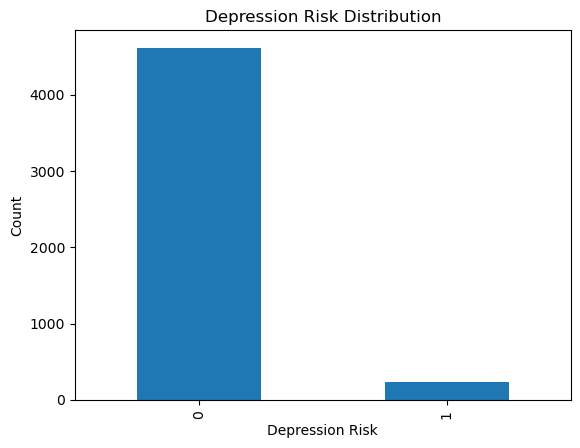

In [8]:
# 타깃 변수 분포
target_count = df_model["depression_risk"].value_counts().sort_index()
target_ratio = df_model["depression_risk"].value_counts(normalize=True).sort_index()

display(pd.DataFrame({"count": target_count, "ratio": target_ratio}))

target_count.plot(kind="bar")
plt.title("Depression Risk Distribution")
plt.xlabel("Depression Risk")
plt.ylabel("Count")
plt.show()

,missing_rate
hear_device_freq,0.984520
tinnitus_dist,0.926522
tinnitus_6mo,0.918266
ear_noise_min,0.885862
hear_device,0.866254
hear_act_limit,0.827864
occ_noise,0.286687
tinnitus,0.286687
hear_status,0.055108
ear_noise,0.055108


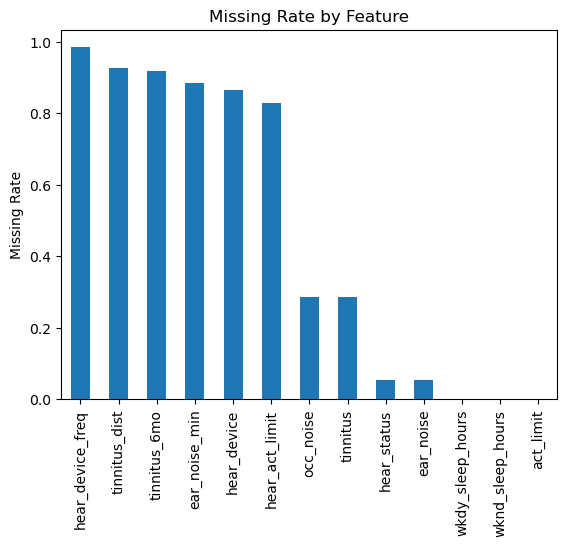

In [9]:
# 입력 변수 결측률
missing_rate = df_model[available_features].isna().mean().sort_values(ascending=False)
display(missing_rate.to_frame("missing_rate"))

missing_rate.plot(kind="bar")
plt.title("Missing Rate by Feature")
plt.ylabel("Missing Rate")
plt.show()

wkdy_sleep_hours                 wknd_sleep_hours           \
                            mean       std count             mean      std   
depression_risk                                                              
0                       6.765191  1.267546  4608         7.507812  1.57703   
1                       6.384279  1.686093   229         7.314410  2.16973   

                       
                count  
depression_risk        
0                4608  
1                 229

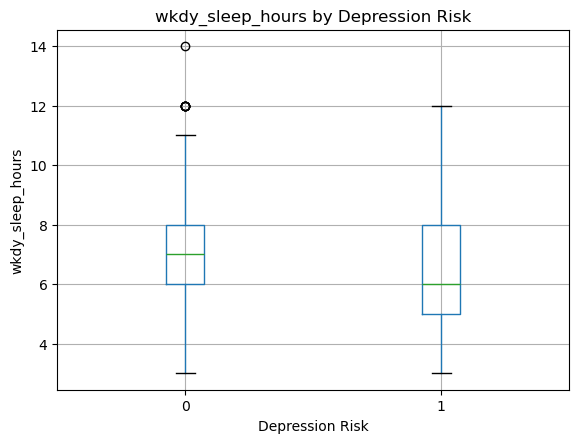

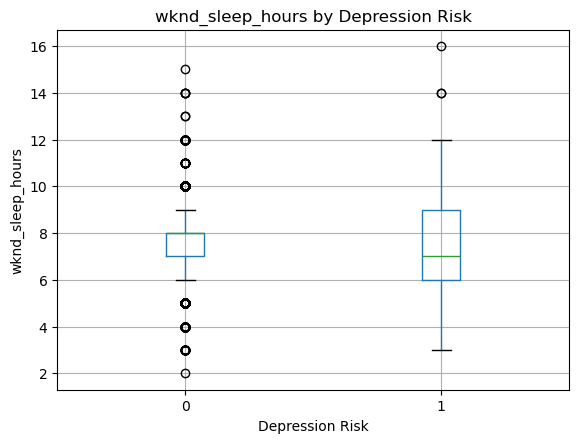

In [10]:
# 우울 위험군 여부에 따른 수면시간 평균 비교
sleep_cols = [col for col in ["wkdy_sleep_hours", "wknd_sleep_hours"] if col in df_model.columns]

if sleep_cols:
    display(df_model.groupby("depression_risk")[sleep_cols].agg(["mean", "std", "count"]))

    for col in sleep_cols:
        df_model.boxplot(column=col, by="depression_risk")
        plt.title(f"{col} by Depression Risk")
        plt.suptitle("")
        plt.xlabel("Depression Risk")
        plt.ylabel(col)
        plt.show()

In [11]:
# 범주형 변수와 우울 위험군의 관계 확인
categorical_preview_cols = [
    "hear_status",
    "occ_noise",
    "ear_noise",
    "tinnitus",
    "tinnitus_6mo",
    "act_limit",
    "hear_act_limit",
]

for col in categorical_preview_cols:
    if col in df_model.columns:
        print(f"\n[{col}] depression_risk 비율")
        display(pd.crosstab(df_model[col], df_model["depression_risk"], normalize="index"))


[hear_status] depression_risk 비율


depression_risk,0,1
hear_status,,
1.0,0.952926,0.047074
2.0,0.953578,0.046422
3.0,0.926230,0.073770
4.0,1.000000,0.000000



[occ_noise] depression_risk 비율


depression_risk,0,1
occ_noise,,
1.0,0.946043,0.053957
2.0,0.960345,0.039655



[ear_noise] depression_risk 비율


...

depression_risk,0,1
tinnitus_6mo,,
1.0,0.936709,0.063291
2.0,0.912500,0.087500



[act_limit] depression_risk 비율


depression_risk,0,1
act_limit,,
1.0,0.866906,0.133094
2.0,0.970309,0.029691



[hear_act_limit] depression_risk 비율


depression_risk,0,1
hear_act_limit,,
0.0,0.863402,0.136598
1.0,0.913793,0.086207


---

# 8. Train/Test Split 및 전처리 파이프라인

결측치 대체, 인코딩, 스케일링은 train/test split 이후 파이프라인 내부에서 수행한다. 이렇게 하면 데이터 누수를 줄일 수 있다.

In [12]:
X = df_model.drop(columns=[col for col in ["id", "depression_risk"] if col in df_model.columns])
y = df_model["depression_risk"]

# 클래스가 하나뿐이면 모델링 불가
if y.nunique() < 2:
    raise ValueError("타깃 클래스가 하나뿐입니다. depression_risk 생성 기준과 데이터 필터링을 확인하세요.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train target ratio")
print(y_train.value_counts(normalize=True).sort_index())
print("Test target ratio")
print(y_test.value_counts(normalize=True).sort_index())

X_train: (3876, 13)
X_test: (969, 13)
Train target ratio
depression_risk
0    0.952528
1    0.047472
Name: proportion, dtype: float64
Test target ratio
depression_risk
0    0.952528
1    0.047472
Name: proportion, dtype: float64


In [13]:
# 수치형 / 범주형 변수 구분
numeric_features = [col for col in ["wkdy_sleep_hours", "wknd_sleep_hours", "ear_noise_min"] if col in X.columns]
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

수치형 변수: ['wkdy_sleep_hours', 'wknd_sleep_hours', 'ear_noise_min']
범주형 변수: ['hear_status', 'hear_device', 'hear_device_freq', 'occ_noise', 'ear_noise', 'tinnitus', 'tinnitus_6mo', 'tinnitus_dist', 'act_limit', 'hear_act_limit']


---

# 9. 모델 학습

동일한 전처리 파이프라인을 사용하여 여러 분류 모델의 성능을 비교한다.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} 학습 완료")

Logistic Regression 학습 완료
Random Forest 학습 완료
Hist Gradient Boosting 학습 완료


---

# 10. 성능 평가

우울 위험군은 소수 클래스일 가능성이 있으므로 Accuracy만으로 성능을 판단하지 않고 Recall, F1-score, ROC-AUC를 함께 확인한다.

In [15]:
def get_positive_score(pipe, X_data):
    """모델별 양성 클래스 점수 추출"""
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        return pipe.predict_proba(X_data)[:, 1]
    if hasattr(pipe.named_steps["model"], "decision_function"):
        return pipe.decision_function(X_data)
    return pipe.predict(X_data)

results = []

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_score = get_positive_score(pipe, X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.787410,0.126168,0.586957,0.207692,0.688586
1,Random Forest,0.812178,0.080247,0.282609,0.125000,0.545480
2,Hist Gradient Boosting,0.943240,0.090909,0.021739,0.035088,0.655012


Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.80      0.88       923
           1       0.13      0.59      0.21        46

    accuracy                           0.79       969
   macro avg       0.55      0.69      0.54       969
weighted avg       0.93      0.79      0.85       969



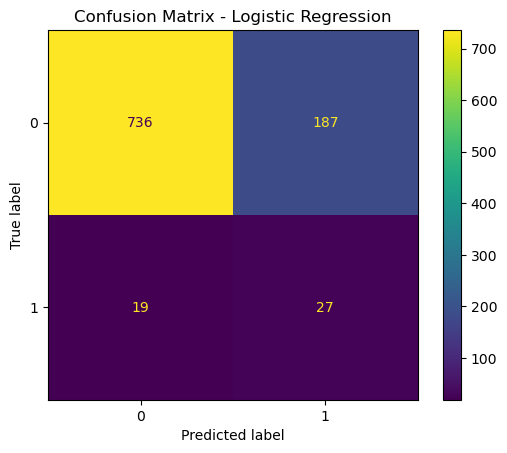

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.84      0.89       923
           1       0.08      0.28      0.12        46

    accuracy                           0.81       969
   macro avg       0.52      0.56      0.51       969
weighted avg       0.92      0.81      0.86       969



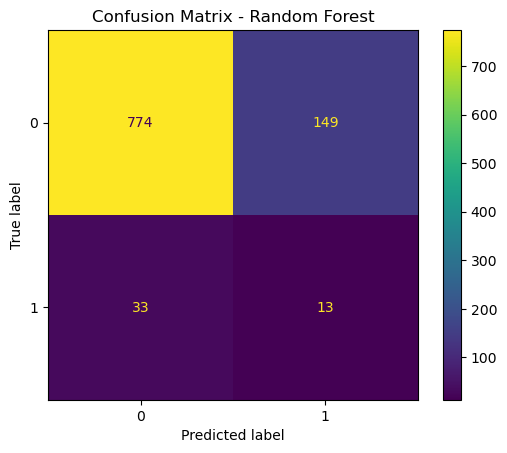

Hist Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       923
           1       0.09      0.02      0.04        46

    accuracy                           0.94       969
   macro avg       0.52      0.51      0.50       969
weighted avg       0.91      0.94      0.93       969



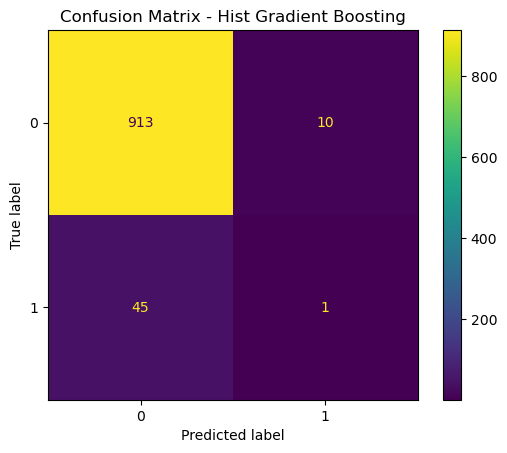

In [16]:
# 모델별 Classification Report 및 Confusion Matrix
for name, pipe in pipelines.items():
    print("=" * 80)
    print(name)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

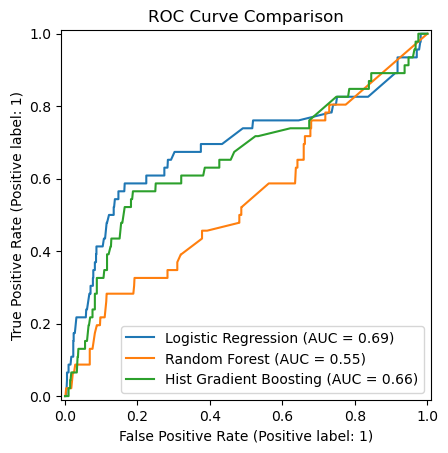

In [17]:
# ROC Curve 비교
ax = plt.gca()
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
plt.title("ROC Curve Comparison")
plt.show()

---

# 11. 변수 중요도 및 해석

Random Forest 또는 Gradient Boosting 계열 모델의 중요도를 확인한다. One-Hot Encoding 이후 변수명이 확장되므로, 전처리 후 feature name을 확인하여 해석한다.

,feature,importance
0,wkdy_sleep_hours,0.258154
1,wknd_sleep_hours,0.229768
33,act_limit_2.0,0.103161
32,act_limit_1.0,0.094733
2,ear_noise_min,0.078231
3,hear_status_1.0,0.023280
4,hear_status_2.0,0.022779
15,occ_noise_2.0,0.018470
14,occ_noise_1.0,0.018096
5,hear_status_3.0,0.015799


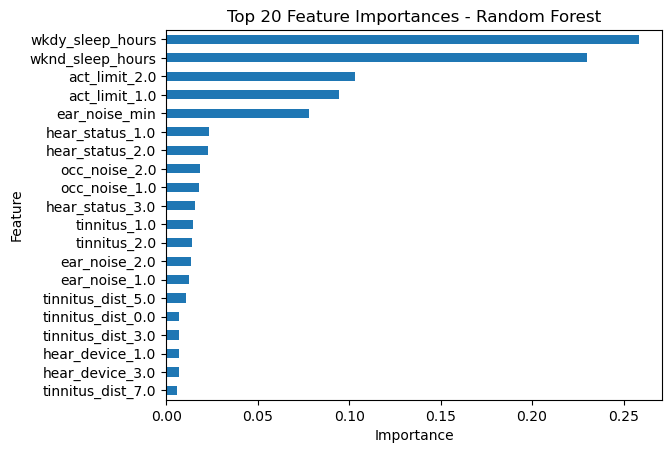

In [18]:
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    if "num" in preprocessor.named_transformers_:
        feature_names.extend(numeric_features)

    if "cat" in preprocessor.named_transformers_ and categorical_features:
        cat_pipeline = preprocessor.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features)
        feature_names.extend(cat_names)

    return np.array(feature_names)

rf_pipe = pipelines["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
feature_names = get_feature_names_from_preprocessor(rf_pipe.named_steps["preprocessor"])

if hasattr(rf_model, "feature_importances_"):
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importances.head(20))

    importances.head(20).sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        legend=False,
    )
    plt.title("Top 20 Feature Importances - Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

,original_feature,importance
0,wkdy_sleep_hours,0.258154
1,wknd_sleep_hours,0.229768
2,act_limit,0.197894
3,ear_noise,0.104020
4,tinnitus,0.088401
5,hear_status,0.062123
6,occ_noise,0.036566
7,hear_device,0.014437
8,hear_act_limit,0.008638


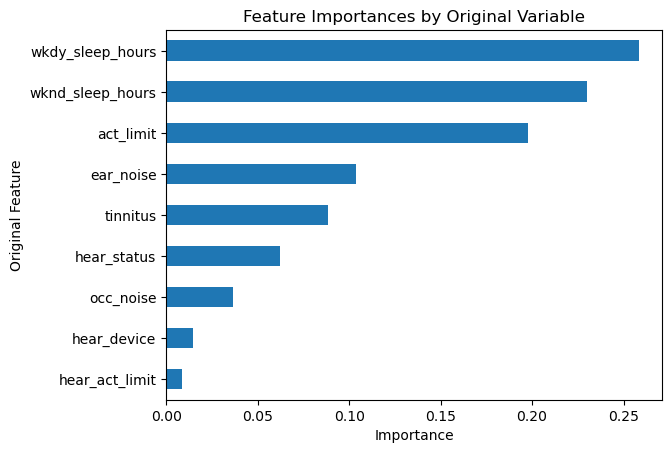

In [19]:
# 원래 변수 단위로 중요도 묶기
if "importances" in globals():
    grouped_importances = importances.copy()

    def map_original_feature(encoded_name):
        for col in categorical_features:
            if encoded_name.startswith(col + "_"):
                return col
        return encoded_name

    grouped_importances["original_feature"] = grouped_importances["feature"].apply(map_original_feature)
    original_importance = (
        grouped_importances.groupby("original_feature")["importance"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    display(original_importance)

    original_importance.sort_values("importance").plot(
        kind="barh",
        x="original_feature",
        y="importance",
        legend=False,
    )
    plt.title("Feature Importances by Original Variable")
    plt.xlabel("Importance")
    plt.ylabel("Original Feature")
    plt.show()

---

# 12. 결과 해석 정리

아래 셀에는 모델 결과를 보고 팀별 관점에서 해석을 작성한다.

## 12.1 모델 성능 해석 예시

- 우울 위험군이 소수 클래스인 경우 Accuracy가 높아도 실제 위험군을 잘 찾지 못할 수 있다.
- 따라서 Recall과 F1-score를 함께 확인해야 한다.
- ROC-AUC는 여러 임계값에서 모델의 구분 성능을 종합적으로 보여준다.

## 12.2 변수 중요도 해석 예시

- 수면시간 변수가 중요하게 나타난 경우, 수면 부족 또는 과다 수면과 우울 위험 사이의 관련성을 논의할 수 있다.
- 청각 상태, 이명, 소음 노출 변수가 중요하게 나타난 경우, 감각적 불편감과 정신건강 사이의 관련성을 논의할 수 있다.
- 단, 본 분석은 단면 자료 기반이므로 인과관계로 해석해서는 안 된다.

In [20]:
# 주요 결과를 간단히 요약하기 위한 셀
best_model_name = results_df.iloc[0]["model"]
best_model_metrics = results_df.iloc[0]

print("가장 높은 F1-score 기준 모델:", best_model_name)
print(best_model_metrics)

if "original_importance" in globals():
    print("\n상위 중요 변수")
    display(original_importance.head(10))

가장 높은 F1-score 기준 모델: Logistic Regression
model        Logistic Regression
accuracy                 0.78741
precision               0.126168
recall                  0.586957
f1                      0.207692
roc_auc                 0.688586
Name: 0, dtype: object

상위 중요 변수


,original_feature,importance
0,wkdy_sleep_hours,0.258154
1,wknd_sleep_hours,0.229768
2,act_limit,0.197894
3,ear_noise,0.104020
4,tinnitus,0.088401
5,hear_status,0.062123
6,occ_noise,0.036566
7,hear_device,0.014437
8,hear_act_limit,0.008638


---

# 13. 결론 및 한계

## 13.1 결론

- 본 프로젝트는 KNHANES 2022 자료를 활용하여 수면시간, 청각 문제, 소음 노출 관련 변수를 바탕으로 우울 위험군 여부를 예측하였다.
- 여러 분류 모델의 성능을 비교하고, Recall, F1-score, ROC-AUC를 중심으로 성능을 평가하였다.
- 변수 중요도를 통해 우울 위험군 예측에 상대적으로 기여한 수면 및 청각 관련 요인을 확인하였다.

## 13.2 한계

- 국민건강영양조사는 단면 자료이므로 인과관계 해석에 한계가 있다.
- 소음 노출 변수는 실제 데시벨 측정값이 아닌 설문 기반 자기보고 변수이다.
- 일부 청각 및 소음 관련 변수는 특정 연령대 또는 조건에만 해당할 수 있어 표본 수가 줄어들 수 있다.
- PHQ-9 총점에는 수면 관련 문항이 포함되어 있어, 수면시간 변수와 타깃 간 개념적 중복 가능성이 있다.
- 본 분석의 우울 위험군 예측은 임상적 진단을 대체할 수 없다.

## 13.3 향후 개선 방향

- 변수별 코드북을 더 엄밀히 반영한 결측 및 비해당 코드 처리
- 연령, 성별, 소득수준 등 인구사회학적 통제 변수 추가
- 40세 이상 등 특정 하위집단 분석 추가
- 모델 하이퍼파라미터 튜닝
- SHAP, LIME 등 설명 가능한 AI 기법 적용